# Notebook 01 — Data Loading

This notebook connects to Google Cloud and verifies that our data pipeline works end to end.

By the end you should be able to:
- Query image metadata from BigQuery
- See the label distribution across the dataset
- Load and display a chest X-ray image from Cloud Storage

---

**Before running this notebook**, make sure you have the credentials file in the right place:

```
configs/nih-xray-ml-8be81f9160f0.json
```

If you don't have this file, ask the team lead — it is not stored in GitHub for security reasons.

## Step 0 — Install dependencies

Run this cell once when setting up your environment. It is safe to run again — it will skip anything already installed.

In [9]:
%pip install \
    google-cloud-bigquery \
    google-cloud-bigquery-storage \
    google-cloud-storage \
    google-auth \
    db-dtypes \
    pyarrow \
    pandas \
    numpy \
    matplotlib \
    Pillow \
    --quiet

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Imports and credentials

We load the service account credentials file from `configs/` and use it to connect to both BigQuery and Cloud Storage.
This avoids any issues with environment variables and works the same way for everyone on the team.

In [10]:
from pathlib import Path
import io

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from google.cloud import bigquery, storage
from google.oauth2 import service_account

In [11]:
CRED_FILENAME = "nih-xray-ml-8be81f9160f0.json"
PROJECT_ID    = "nih-xray-ml"
BUCKET_NAME   = "nih-xray-images-mdfnb"

# Search for the credentials file starting from this notebook's location up to the repo root
search_roots = [Path.cwd(), *Path.cwd().parents[:4]]
cred_path = next(
    (r / "configs" / CRED_FILENAME for r in search_roots if (r / "configs" / CRED_FILENAME).exists()),
    None
)

if cred_path is None:
    raise FileNotFoundError(
        f"Could not find '{CRED_FILENAME}' in any configs/ folder. "
        "Ask the team lead for this file and place it in configs/."
    )

credentials = service_account.Credentials.from_service_account_file(str(cred_path))
print("Credentials loaded from:", cred_path)

bq_client      = bigquery.Client(project=PROJECT_ID, credentials=credentials)
storage_client = storage.Client(project=PROJECT_ID, credentials=credentials)
print("Connected to BigQuery and Cloud Storage.")

Credentials loaded from: /Users/eva-01/Documents/PSTAT 134/pstat-134-spring2026/X-Ray-classification/configs/nih-xray-ml-8be81f9160f0.json
Connected to BigQuery and Cloud Storage.


## Step 2 — Query metadata from BigQuery

The metadata table has one row per image. The two columns we care about right now are:
- `Image Index` — the filename (e.g. `00000001_000.png`)
- `Finding Labels` — the condition(s) found in the image (e.g. `Infiltration|Nodule` or `No Finding`)

Multiple conditions are separated by `|`. We will parse these into a binary label in Phase 2.

In [12]:
query = """
SELECT
    `Image Index`,
    `Finding Labels`
FROM `nih-xray-ml.nih_xray.metadata`
LIMIT 10
"""

df_sample = bq_client.query(query).to_dataframe(create_bqstorage_client=False)
df_sample

,Image Index,Finding Labels
0,00010493_000.png,No Finding
1,00012654_001.png,Infiltration
2,00013401_000.png,Pleural_Thickening
3,00014351_000.png,No Finding
4,00017538_001.png,No Finding
5,00018069_001.png,No Finding
6,00006649_000.png,Effusion|Infiltration
7,00009573_000.png,No Finding
8,00010124_000.png,No Finding
9,00010230_000.png,No Finding


## Step 3 — Check the label distribution

Before building any model we need to understand the class balance. This query counts how often each label combination appears across all 112k images.

Key things to notice:
- `No Finding` is by far the most common label (~60k out of 112k images)
- Everything else is a disease label — some appear alone, some appear combined with `|`
- This imbalance is something we will have to handle carefully in Phase 4 and 5

In [13]:
query_dist = """
SELECT
    `Finding Labels`,
    COUNT(*) AS count
FROM `nih-xray-ml.nih_xray.metadata`
GROUP BY `Finding Labels`
ORDER BY count DESC
LIMIT 20
"""

df_dist = bq_client.query(query_dist).to_dataframe(create_bqstorage_client=False)
print(df_dist.to_string(index=False))

                   Finding Labels  count
                       No Finding  60361
                     Infiltration   9547
                      Atelectasis   4215
                         Effusion   3955
                           Nodule   2705
                     Pneumothorax   2194
                             Mass   2139
            Effusion|Infiltration   1603
         Atelectasis|Infiltration   1350
                    Consolidation   1310
             Atelectasis|Effusion   1165
               Pleural_Thickening   1126
                     Cardiomegaly   1093
                        Emphysema    892
              Infiltration|Nodule    829
Atelectasis|Effusion|Infiltration    737
                         Fibrosis    727
                            Edema    628
            Cardiomegaly|Effusion    484
       Consolidation|Infiltration    441


## Step 4 — Find images available in our bucket

We have only uploaded a subset of images to our Cloud Storage bucket so far. This cell:
1. Lists every file actually in the bucket
2. Queries BigQuery for metadata matching only those files

This gives us a working dataset — the intersection of what is uploaded and what has metadata.

In [14]:
# Get the filename for every image currently in the bucket
uploaded_filenames = [
    blob.name.split("/")[-1]
    for blob in storage_client.list_blobs(BUCKET_NAME)
]

print(f"Images available in bucket: {len(uploaded_filenames)}")
print("Sample filenames:", uploaded_filenames[:5])

Images available in bucket: 528
Sample filenames: ['00000001_000.png', '00000001_001.png', '00000005_000.png', '00000006_000.png', '00000011_000.png']


In [15]:
# Query metadata for only the images we have in the bucket
# We cap at 500 filenames to stay within BigQuery query size limits
filenames_sql = ", ".join(f"'{f}'" for f in uploaded_filenames[:500])

query_available = f"""
SELECT `Image Index`, `Finding Labels`
FROM `nih-xray-ml.nih_xray.metadata`
WHERE `Image Index` IN ({filenames_sql})
"""

df = bq_client.query(query_available).to_dataframe(create_bqstorage_client=False)
print(f"Images with metadata: {len(df)}")
df.head(10)

Images with metadata: 500


,Image Index,Finding Labels
0,00001072_000.png,No Finding
1,00001255_009.png,Infiltration|Nodule
2,00001255_019.png,Consolidation
3,00001255_025.png,Cardiomegaly|Infiltration
4,00001255_035.png,No Finding
5,00001054_002.png,Atelectasis|Pneumonia
6,00001255_021.png,Infiltration
7,00001255_031.png,Infiltration|Pneumonia
8,00001054_003.png,No Finding
9,00001238_002.png,No Finding


## Step 5 — Load and display a chest X-ray

This is the final check: confirm we can actually pull an image from Cloud Storage and display it.
We use the first image from our available dataset and search across all subfolders in the bucket.

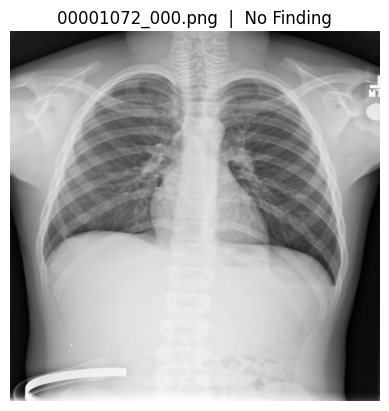

Phase 1 complete — data pipeline is working.


In [16]:
image_filename = df["Image Index"].iloc[0]
label          = df["Finding Labels"].iloc[0]

# Search all subfolders in the bucket for this filename
blobs = list(storage_client.list_blobs(BUCKET_NAME, match_glob=f"**/images/{image_filename}"))

if not blobs:
    print(f"Image not found in bucket: {image_filename}")
else:
    img_bytes = blobs[0].download_as_bytes()
    img = Image.open(io.BytesIO(img_bytes))

    plt.imshow(img, cmap="gray")
    plt.title(f"{image_filename}  |  {label}")
    plt.axis("off")
    plt.show()
    print("Phase 1 complete — data pipeline is working.")